Patients: 3000
Disease prevalence: 30.5%
disease
No disease    2086
Disease        914
Name: count, dtype: int64
lr_split
train         2400
validation     600
Name: count, dtype: int64


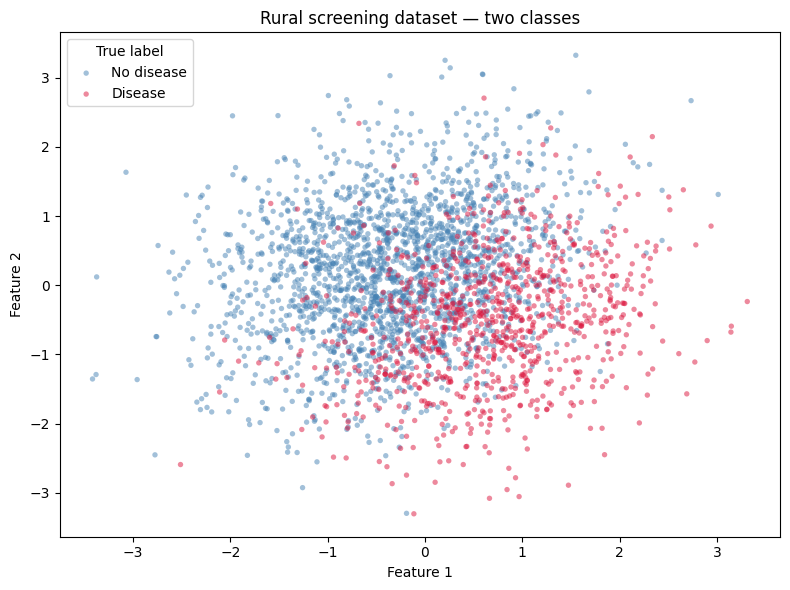

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/rural_screening.csv")

print(f"Patients: {len(df)}")
print(f"Disease prevalence: {df['disease'].mean():.1%}")
print(df["disease"].value_counts().rename({0: "No disease", 1: "Disease"}))
print(df["lr_split"].value_counts())

fig, ax = plt.subplots(figsize=(8, 6))

for label, color, name in [(0, "steelblue", "No disease"), (1, "crimson", "Disease")]:
    mask = df["disease"] == label
    ax.scatter(
        df.loc[mask, "feature 1"],
        df.loc[mask, "feature 2"],
        c=color,
        label=name,
        alpha=0.5,
        s=15,
        edgecolors="none",
    )

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Rural screening dataset — two classes")
ax.legend(title="True label")
plt.tight_layout()
plt.show()

---
#### 🟢 Station 2 — Train a baseline MLP

We train a small neural network for 100 epochs on the two features. The train/hold-out split comes from the `lr_split` column in the CSV.

**Toggles to experiment with later:**
- `MC_DROPOUT = True` — adds dropout layers during training (regularization)
- `MC_UNCERTAINTY = True` — keeps dropout on at prediction time to estimate uncertainty (Station 3)

In [2]:
# ============================================================
# Station 2 — Train the MLP
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# --- Settings you can change ---
SEED = 43
MC_DROPOUT = False      # True = add dropout layers (used in Stations 4+)
MC_UNCERTAINTY = False  # True = estimate uncertainty at prediction time (Station 4)
MC_SAMPLES = 50         # how many forward passes for MC Dropout
DROPOUT_P = 0.2
THRESHOLD = 0.5         # referral threshold used later in the notebook

# Fix random seeds so results are reproducible
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- 1. Split the data ---
# The CSV tells us which patients were "train" vs "validation"
# for the original logistic model. We reuse that same split.
train_idx = df.index[df["lr_split"] == "train"]
holdout_idx = df.index[df["lr_split"] == "validation"]

# Keep these names for later cells
val_idx = holdout_idx
test_idx = holdout_idx

FEATURE_COLS = ["feature 1", "feature 2"]

X_train = df.loc[train_idx, FEATURE_COLS].to_numpy(np.float32)
X_holdout = df.loc[holdout_idx, FEATURE_COLS].to_numpy(np.float32)
y_train = df.loc[train_idx, "disease"].to_numpy(np.float32)
y_holdout = df.loc[holdout_idx, "disease"].to_numpy(np.float32)

# --- 2. Standardize features ---
# Important: fit the scaler on training data only, then apply to holdout
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_holdout = scaler.transform(X_holdout).astype(np.float32)

# Later cells use these names — they all point to the same hold-out patients
X_val = X_holdout
X_test = X_holdout
y_val = y_holdout
y_test = y_holdout

print(f"Train patients: {len(train_idx)}")
print(f"Hold-out patients: {len(holdout_idx)}")

# --- 3. Define the MLP ---
# Architecture: Linear → ReLU → [Dropout] → Linear → ReLU → [Dropout] → Linear
# The last layer outputs a single logit (not a probability yet).

class MLP(nn.Module):
    def __init__(self, n_features, use_dropout=False, dropout_p=0.2):
        super().__init__()
        layers = [
            nn.Linear(n_features, 32),
            nn.ReLU(),
        ]
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))
        layers += [
            nn.Linear(32, 16),
            nn.ReLU(),
        ]
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))
        layers.append(nn.Linear(16, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)  # shape: (n_patients,)


model = MLP(len(FEATURE_COLS), use_dropout=MC_DROPOUT, dropout_p=DROPOUT_P)

# --- 4. Set up training ---
# BCEWithLogitsLoss expects raw logits + 0/1 labels
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Convert numpy arrays to torch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)

# --- 5. Train for 100 epochs ---
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()

print("Training finished (100 epochs)")

Split from `lr_split` column
STRATIFY=False | MC_DROPOUT=False
Input dimension (after preprocessing): 2
Train: 2400 | Validation (early stopping): 600 | Hold-out eval: 600
Train prevalence: 30.5% | Val: 30.5% | Hold-out: 30.5%
Training stopped at epoch 100 (best validation loss: 0.4509)

Hold-out set (n=600, lr_split=validation):
  Accuracy (threshold=0.5): 0.830
  Brier score: 0.1398
  Predicted probabilities: min=0.081, max=0.969, mean=0.395


In [ ]:
# ============================================================
# Station 2 — Get prediction scores
# ============================================================
from sklearn.metrics import brier_score_loss


def predict_proba(model, X):
    """Standard prediction: dropout OFF, convert logits → probabilities."""
    model.eval()
    with torch.no_grad():
        X_t = torch.from_numpy(X.astype(np.float32))
        logits = model(X_t)
        return torch.sigmoid(logits).numpy()


def predict_proba_mc(model, X, n_samples=50):
    """MC Dropout: dropout stays ON, run many passes, return mean + std."""
    X_t = torch.from_numpy(X.astype(np.float32))
    model.train()  # this keeps dropout active!
    samples = []
    with torch.no_grad():
        for _ in range(n_samples):
            samples.append(torch.sigmoid(model(X_t)).numpy())
    model.eval()
    samples = np.stack(samples)
    return samples.mean(axis=0), samples.std(axis=0)


# --- Predict on the hold-out set ---
if MC_UNCERTAINTY and MC_DROPOUT:
    test_probs, test_uncertainty = predict_proba_mc(model, X_test, n_samples=MC_SAMPLES)
elif MC_UNCERTAINTY and not MC_DROPOUT:
    print("MC_UNCERTAINTY needs MC_DROPOUT=True — using standard prediction.")
    test_probs = predict_proba(model, X_test)
    test_uncertainty = None
else:
    test_probs = predict_proba(model, X_test)
    test_uncertainty = None

# --- Evaluate on hold-out ---
print(f"Hold-out patients: {len(test_idx)}")
print(f"Brier score: {brier_score_loss(y_test, test_probs):.4f}")

---
#### 🟢 Station 3 — Per-patient uncertainty (MC Dropout)

When `MC_UNCERTAINTY = True`, each hold-out patient gets a **mean predicted risk** and an **uncertainty** estimate (std across MC samples).

In [4]:
# ============================================================
# Station 3 — Per-patient uncertainty (MC Dropout)
# ============================================================
# Only runs when both MC_DROPOUT and MC_UNCERTAINTY are True.
# test_probs and test_uncertainty come from the prediction cell above.

if MC_UNCERTAINTY and MC_DROPOUT:
    uncertainty_df = pd.DataFrame({
        "predicted_risk": test_probs,
        "uncertainty": test_uncertainty,
        "disease": y_test.astype(int),
    }, index=test_idx)

    print("Top 10 most uncertain patients:")
    display(uncertainty_df.sort_values("uncertainty", ascending=False).head(10)
            .style.format({"predicted_risk": "{:.3f}", "uncertainty": "{:.3f}"}))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(test_uncertainty, bins=30, edgecolor="black")
    axes[0].set(xlabel="Uncertainty (std)", ylabel="Count", title="Distribution of uncertainty")

    sc = axes[1].scatter(test_probs, test_uncertainty, c=y_test, cmap="coolwarm", alpha=0.6, s=15)
    axes[1].set(xlabel="Mean predicted risk", ylabel="Uncertainty", title="Risk vs uncertainty")
    plt.colorbar(sc, ax=axes[1], label="Disease")
    plt.tight_layout()
    plt.show()
else:
    print("Set MC_DROPOUT=True and MC_UNCERTAINTY=True to see uncertainty estimates.")

Set MC_DROPOUT=True and MC_UNCERTAINTY=True to see per-patient uncertainty estimates.


---
#### Compare to the original model scores

The CSV includes `predicted_risk` from the undisclosed screening model (Part 1). How do our vanilla MLP predictions compare on the hold-out validation split (`lr_split == "validation"`)?

Hold-out validation set (n=600): Pearson r = 0.946


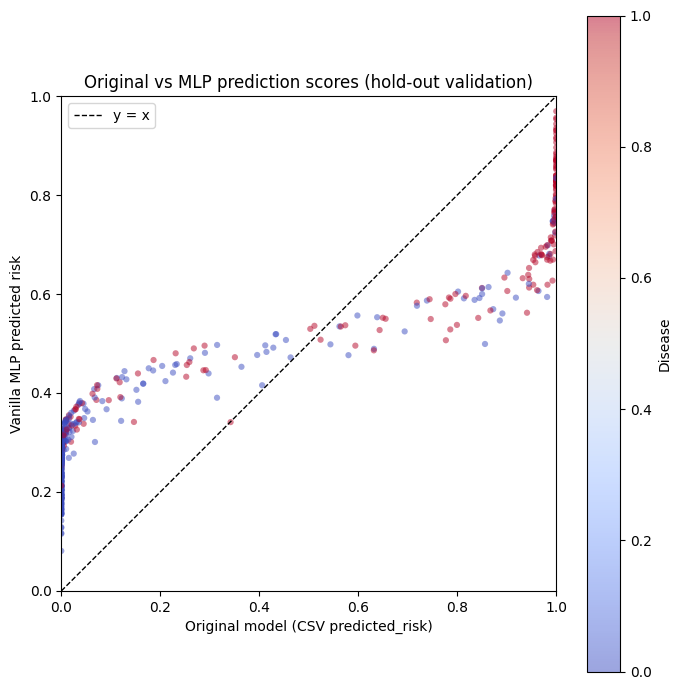

In [5]:
# ============================================================
# Compare original model vs our MLP on the hold-out set
# ============================================================
csv_scores = df.loc[test_idx, "predicted_risk"].to_numpy()
mlp_scores = test_probs

print(f"Pearson correlation: {np.corrcoef(csv_scores, mlp_scores)[0, 1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(csv_scores, mlp_scores, c=y_test, cmap="coolwarm", alpha=0.5, s=20)
ax.plot([0, 1], [0, 1], "k--", label="y = x")
ax.set(xlabel="Original model (CSV)", ylabel="Our MLP", title="Prediction scores on hold-out",
       xlim=(0, 1), ylim=(0, 1), aspect="equal")
ax.legend()
plt.colorbar(sc, ax=ax, label="Disease")
plt.tight_layout()
plt.show()

---
#### Where do the two models disagree?

At threshold 0.5, how often do the original model and vanilla MLP make different referral decisions? When they disagree, which model is correct more often?

In [6]:
# ============================================================
# Where do the two models disagree? (threshold = 0.5)
# ============================================================
csv_preds = (csv_scores >= THRESHOLD).astype(int)
mlp_preds = (mlp_scores >= THRESHOLD).astype(int)
disagree = csv_preds != mlp_preds

n_holdout = len(test_idx)
n_disagree = int(disagree.sum())
original_correct = int((y_test[disagree] == csv_preds[disagree]).sum())
mlp_correct = int((y_test[disagree] == mlp_preds[disagree]).sum())

print(f"Same prediction:    {n_holdout - n_disagree} / {n_holdout}")
print(f"Different prediction: {n_disagree} / {n_holdout}")
if n_disagree:
    print(f"  → Original correct: {original_correct} ({100*original_correct/n_disagree:.1f}% of disagreements)")
    print(f"  → MLP correct:      {mlp_correct} ({100*mlp_correct/n_disagree:.1f}% of disagreements)")

display(pd.DataFrame({
    "": ["Agree", "Disagree", "Original correct (when disagree)", "MLP correct (when disagree)"],
    "Patients": [n_holdout - n_disagree, n_disagree, original_correct, mlp_correct],
}))

Hold-out patients: 600
Same prediction: 591 (98.5%)
Different prediction: 9 (1.5%)

When predictions differ (n=9):
  Original model correct: 5 (55.6%)
  Vanilla MLP correct:    4 (44.4%)


,,Patients,% of hold-out,% when models disagree
0,Same prediction,591,98.5%,—
1,Different prediction,9,1.5%,—
2,— original correct,5,0.8%,55.6%
3,— vanilla MLP correct,4,0.7%,44.4%
